In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [3]:
csv_path = "train.csv"

df = pd.read_csv(csv_path)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index().sort_values("Order Date")

scaler = MinMaxScaler()
scaled = scaler.fit_transform(daily_sales["Sales"].values.reshape(-1,1))

window = 7  # sesuai permintaan
X, y = [], []
for i in range(len(scaled) - window):
    X.append(scaled[i:i+window])
    y.append(scaled[i+window])
X = np.array(X)  # shape (samples, window, 1)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [4]:
tf.random.set_seed(42)
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window,1)),
    GRU(32, return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)
mc = ModelCheckpoint("best_lstm_gru.h5", monitor='val_loss', save_best_only=True)

c:\Users\Asus\Downloads\Tugas Kuliah Semester 5\AI\03_RNN_AI\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,849 (104.88 KB)

 Trainable params: 26,849 (104.88 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[es, rlr, mc],
    verbose=1
)

Epoch 1/80
44/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0067 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 2/80
41/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0063 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 3/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 5/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 6/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 7/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 8/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0081 - learning_rate: 5.0000e-04
Epoch 9/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0081 - learning_rate: 5.0000e-04
Epoch 10/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_loss: 0.0080 - learning_rate: 5.0000e-04
Epoch 11/80
62/62 ━━━━━━━━

In [6]:
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [7]:
mae = mean_absolute_error(y_true, pred)
rmse = root_mean_squared_error(y_true, pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1711.9505
RMSE: 2503.6274


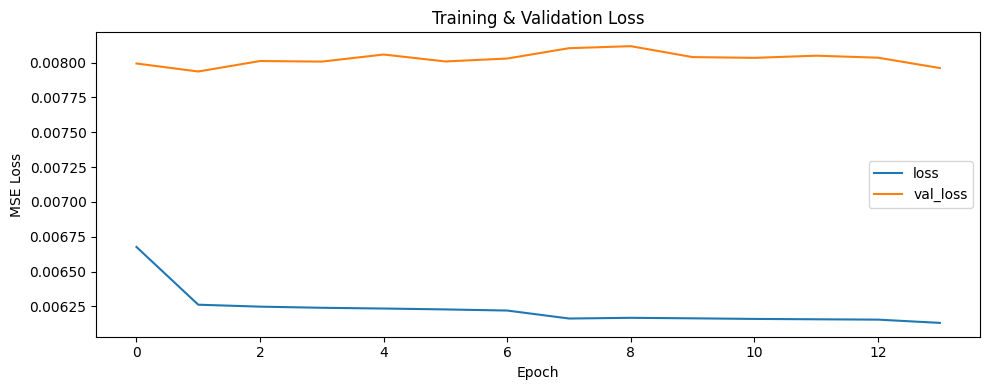

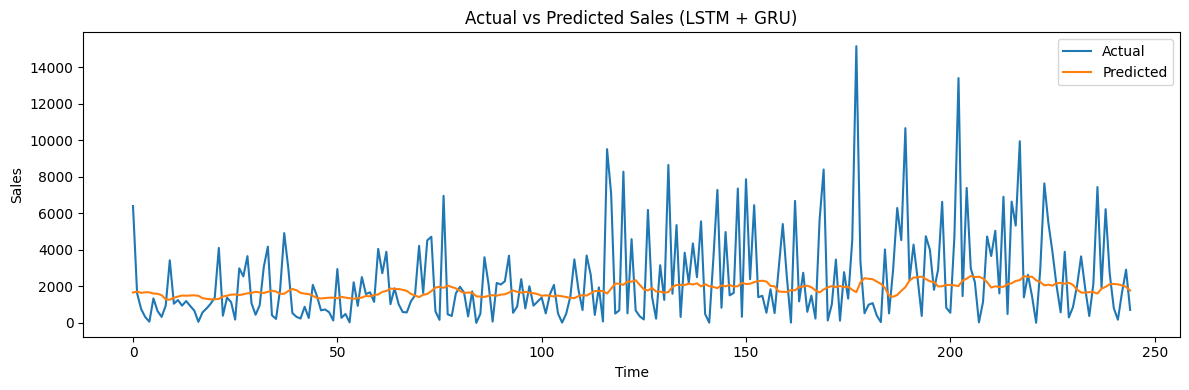

In [8]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(y_true, label='Actual')
plt.plot(pred, label='Predicted')
plt.title('Actual vs Predicted Sales (LSTM + GRU)')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Opsional kalo mu simpan ke csv hasil prediksinya
out_df = pd.DataFrame({
    'Actual': y_true.flatten(),
    'Predicted': pred.flatten()
})
out_df.to_csv("predictions.csv", index=False)
print("Saved predictions.csv")

Saved predictions.csv
